<a href="https://colab.research.google.com/github/zeynepsinal/F-NANSAL-VER-RET-M-/blob/main/F%C4%B0NANSAL_VER%C4%B0_%C3%9CRET%C4%B0M%C4%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gerekli Kütüphanelerin Yüklenmesi**

In [ ]:
!pip install -q sdv pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


**Elimizdeki verileri inceliyoruz ve düzenliyoruz.**

In [ ]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]

try:
    df = pd.read_csv(file_name)
    if df.shape[1] == 1:
        df = pd.read_csv(file_name, sep=";")
except:
    df = pd.read_csv(file_name, sep=";")

print("Veri boyutu:", df.shape)
display(df.head())


Veri boyutu: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
print("Sütunlar:")
print(df.columns.tolist())

print("\nEksik değerler:")
print(df.isnull().sum())

possible_targets = ["y", "deposit", "target", "subscribed"]
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    print("\nHedef sütun otomatik bulunamadı.")
    target_col = input("Hedef sütun adını yaz: ").strip()

print("\nHedef sütun:", target_col)

df = df.dropna(how="all").copy()

Sütunlar:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Eksik değerler:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Hedef sütun: deposit


**Eğitim ve Test Modellerinin Ayrılması**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_real_df = pd.concat([X_train_real, y_train_real], axis=1)
test_real_df = pd.concat([X_test_real, y_test_real], axis=1)

print("\nGerçek train boyutu:", train_real_df.shape)
print("Gerçek test boyutu:", test_real_df.shape)



Gerçek train boyutu: (8929, 17)
Gerçek test boyutu: (2233, 17)


In [ ]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(data=train_real_df)
print("\nMetadata oluşturuldu.") #Metadata, veri setindeki değişkenlerin anlamını ve veri tiplerini açıklamak için oluşturulmuştur. Bu sayede modelin veriyi doğru şekilde öğrenmesi sağlanmıştır.


Metadata oluşturuldu.


**CTGAN ile senteik veri oluşturulması**

In [ ]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,
    verbose=True,
    enable_gpu=True
)

synthesizer.fit(train_real_df)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.90) | Discrim. (-00.20): 100%|██████████| 300/300 [09:50<00:00,  1.97s/it]


In [ ]:
synthetic_train_df = synthesizer.sample(num_rows=len(train_real_df) * 3)

print("\nSentetik train verisi:")
display(synthetic_train_df.head())

synthetic_train_df.to_csv("synthetic_train_data.csv", index=False)


Sentetik train verisi:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,49,technician,married,unknown,no,2,yes,no,unknown,22,jul,105,1,-1,0,unknown,no
1,34,management,single,tertiary,no,1036,no,no,cellular,9,aug,249,1,1,0,unknown,yes
2,38,blue-collar,married,secondary,no,31,yes,yes,unknown,8,may,1188,3,-1,0,unknown,yes
3,41,management,married,tertiary,no,999,yes,no,cellular,7,aug,105,2,341,2,failure,no
4,38,retired,divorced,secondary,no,117,yes,no,unknown,14,nov,319,1,0,0,unknown,yes


In [ ]:
X_test = test_real_df.drop(columns=[target_col]).copy()
y_test = test_real_df[target_col].copy()

X_train_only_real = train_real_df.drop(columns=[target_col]).copy()
y_train_only_real = train_real_df[target_col].copy()

X_train_only_syn = synthetic_train_df.drop(columns=[target_col]).copy()
y_train_only_syn = synthetic_train_df[target_col].copy()

X_train_aug = pd.concat([X_train_only_real, X_train_only_syn], ignore_index=True)
y_train_aug = pd.concat([y_train_only_real, y_train_only_syn], ignore_index=True)  #Sentetik verilerin eğitimi için train ve test olarak verileri ikiye ayırdım.

## Model ve Ön İşleme

Bu çalışmada sınıflandırma modeli olarak Lojistik Regresyon kullanılmıştır. Modelden önce veri ön işleme adımı uygulanmıştır.

Kategorik değişkenler One-Hot Encoding yöntemi ile sayısal forma dönüştürülmüş, sayısal değişkenler ise doğrudan modele verilmiştir. Bu işlemler ColumnTransformer kullanılarak gerçekleştirilmiştir.

Ön işleme ve model adımları Pipeline yapısı içerisinde birleştirilerek daha düzenli ve hatasız bir eğitim süreci sağlanmıştır.

Model performansı Accuracy ve F1-score metrikleri ile değerlendirilmiştir. F1-score hesaplanırken veri setindeki pozitif sınıf otomatik olarak belirlenmiştir.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

cat_cols = X_train_only_real.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train_only_real.select_dtypes(exclude=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

def build_model():
    return Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=2000))
    ])

# F1 için pozitif sınıfı bul
unique_labels = list(pd.Series(y).unique())
positive_label = None

for candidate in ["yes", 1, "1", True]:
    if candidate in unique_labels:
        positive_label = candidate
        break

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    if len(unique_labels) == 2:
        if positive_label is not None:
            f1 = f1_score(y_true, y_pred, pos_label=positive_label)
        else:
            f1 = f1_score(y_true, y_pred, average="binary")
    else:
        f1 = f1_score(y_true, y_pred, average="weighted")

    return acc, f1

In [ ]:
model_real = build_model()
model_real.fit(X_train_only_real, y_train_only_real)
pred_real = model_real.predict(X_test)

acc_real, f1_real = compute_metrics(y_test, pred_real)

print("\n==============================")
print("DENEY 1 — SADECE GERÇEK VERİ")
print("==============================")
print("Accuracy:", acc_real)
print("F1-score:", f1_real)
print(classification_report(y_test, pred_real))


DENEY 1 — SADECE GERÇEK VERİ
Accuracy: 0.8271383788625168
F1-score: 0.8146013448607109
              precision    recall  f1-score   support

          no       0.83      0.85      0.84      1175
         yes       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model_syn = build_model()
model_syn.fit(X_train_only_syn, y_train_only_syn)
pred_syn = model_syn.predict(X_test)

acc_syn, f1_syn = compute_metrics(y_test, pred_syn)

print("\n==============================")
print("DENEY 2 — SADECE SENTETİK VERİ")
print("==============================")
print("Accuracy:", acc_syn)
print("F1-score:", f1_syn)
print(classification_report(y_test, pred_syn))


DENEY 2 — SADECE SENTETİK VERİ
Accuracy: 0.7599641737572772
F1-score: 0.7605004468275246
              precision    recall  f1-score   support

          no       0.80      0.72      0.76      1175
         yes       0.72      0.80      0.76      1058

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model_aug = build_model()
model_aug.fit(X_train_aug, y_train_aug)
pred_aug = model_aug.predict(X_test)

acc_aug, f1_aug = compute_metrics(y_test, pred_aug)

print("\n========================================")
print("DENEY 3 — GERÇEK + SENTETİK VERİ")
print("========================================")
print("Accuracy:", acc_aug)
print("F1-score:", f1_aug)
print(classification_report(y_test, pred_aug))



DENEY 3 — GERÇEK + SENTETİK VERİ
Accuracy: 0.8007165248544559
F1-score: 0.7950253339474896
              precision    recall  f1-score   support

          no       0.83      0.79      0.81      1175
         yes       0.78      0.82      0.80      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
results = pd.DataFrame({
    "Deney": [
        "Sadece Gerçek Veri",
        "Sadece Sentetik Veri",
        "Gerçek + Sentetik Veri"
    ],
    "Accuracy": [acc_real, acc_syn, acc_aug],
    "F1-score": [f1_real, f1_syn, f1_aug]
})

print("\n=== SONUÇ TABLOSU ===")
display(results)



=== SONUÇ TABLOSU ===


,Deney,Accuracy,F1-score
0,Sadece Gerçek Veri,0.827138,0.814601
1,Sadece Sentetik Veri,0.759964,0.760500
2,Gerçek + Sentetik Veri,0.800717,0.795025


Sentetik Veri ve Gerçek Veriyi Karşılaştırabilmek adına bazı grafikler ve korelasyon matrisi oluşturdum.

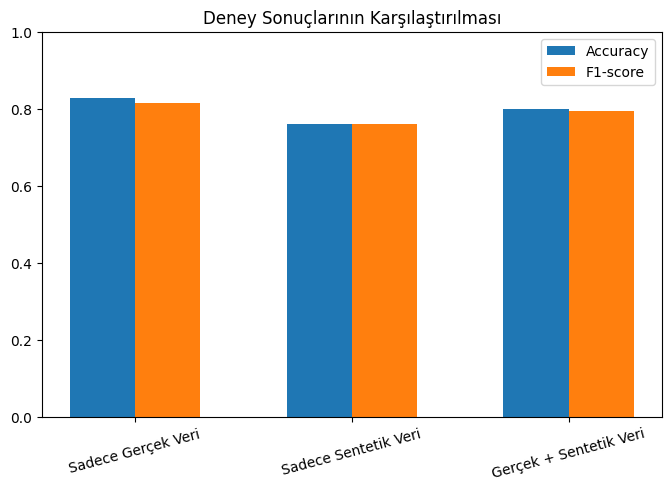

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
x = np.arange(len(results))

plt.bar(x - 0.15, results["Accuracy"], width=0.3, label="Accuracy")
plt.bar(x + 0.15, results["F1-score"], width=0.3, label="F1-score")

plt.xticks(x, results["Deney"], rotation=15)
plt.ylim(0, 1)
plt.title("Deney Sonuçlarının Karşılaştırılması")
plt.legend()
plt.show()

Sayısal sütunlar: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


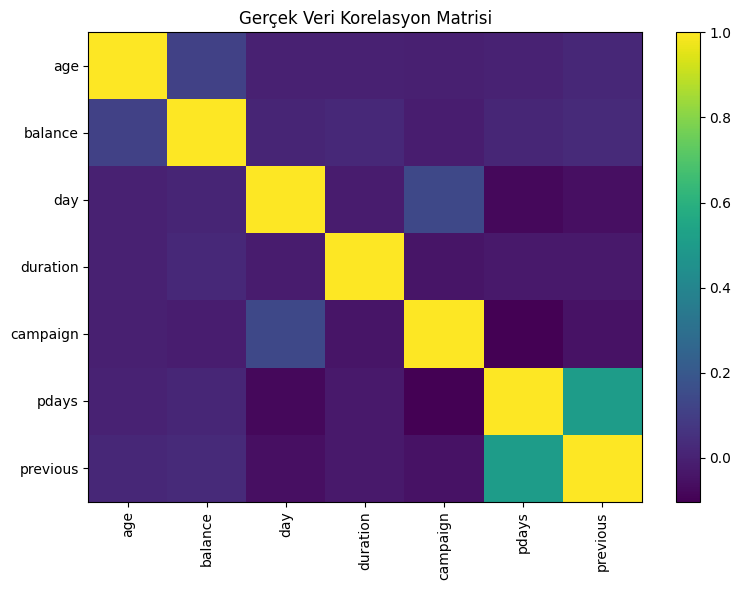

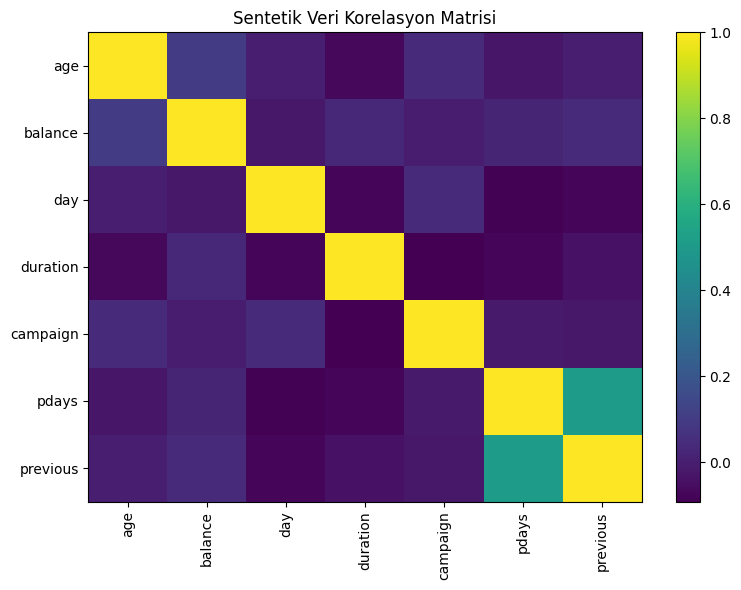

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Sayısal sütunlar:", numeric_cols)

if len(numeric_cols) == 0:
    print("Sayısal sütun bulunamadı. Veri tiplerini kontrol et:")
    print(df.dtypes)
else:
    real_corr = df[numeric_cols].corr()
    syn_corr = synthetic_train_df[numeric_cols].corr()

    plt.figure(figsize=(8,6))
    plt.imshow(real_corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(real_corr.columns)), real_corr.columns, rotation=90)
    plt.yticks(range(len(real_corr.columns)), real_corr.columns)
    plt.title("Gerçek Veri Korelasyon Matrisi")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,6))
    plt.imshow(syn_corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(syn_corr.columns)), syn_corr.columns, rotation=90)
    plt.yticks(range(len(syn_corr.columns)), syn_corr.columns)
    plt.title("Sentetik Veri Korelasyon Matrisi")
    plt.tight_layout()
    plt.show()

Sayısal sütunlar: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kategorik sütunlar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


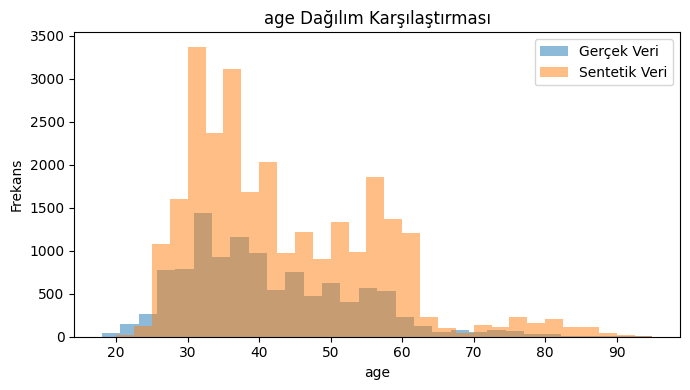

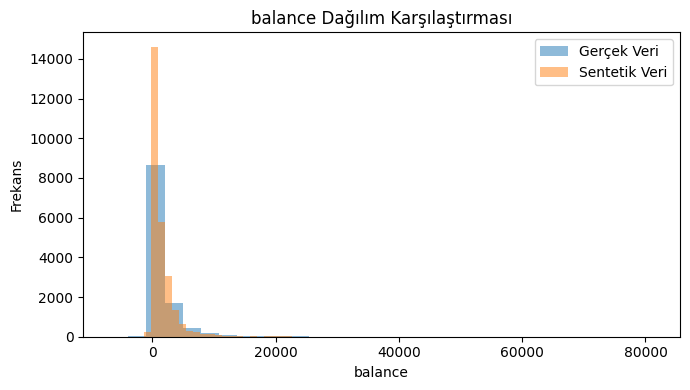

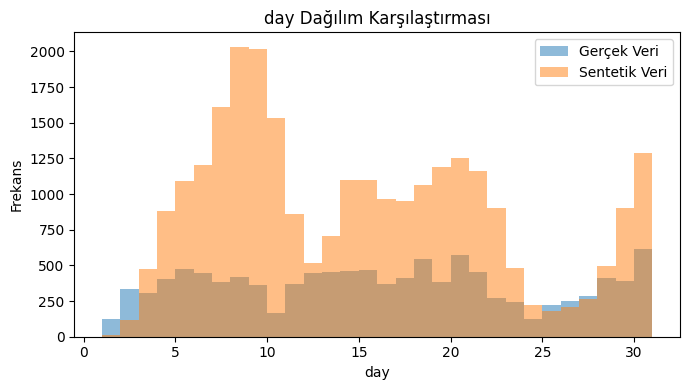

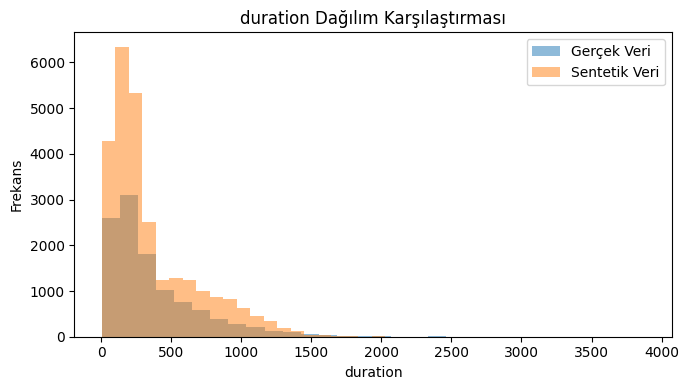

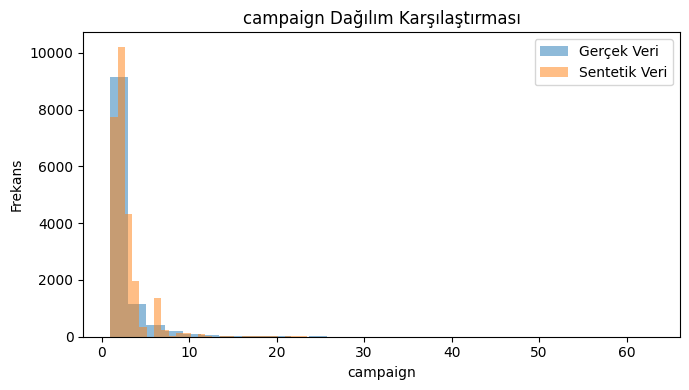

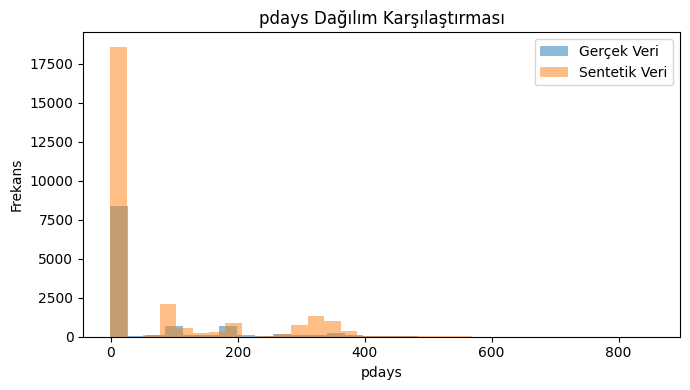

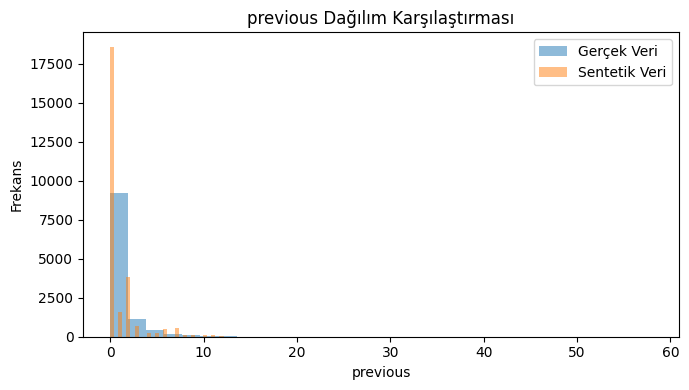

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


real_df = df.copy()
syn_df = synthetic_train_df.copy()

syn_df = syn_df[real_df.columns]

target_col = "deposit"

if target_col in real_df.columns:
    real_features = real_df.drop(columns=[target_col])
    syn_features = syn_df.drop(columns=[target_col])
else:
    real_features = real_df.copy()
    syn_features = syn_df.copy()

numeric_cols = real_features.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

categorical_cols = real_features.select_dtypes(include=["object", "category"]).columns.tolist()

print("Sayısal sütunlar:", numeric_cols)
print("Kategorik sütunlar:", categorical_cols)

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.hist(real_features[col].dropna(), bins=30, alpha=0.5, label="Gerçek Veri")
    plt.hist(syn_features[col].dropna(), bins=30, alpha=0.5, label="Sentetik Veri")
    plt.title(f"{col} Dağılım Karşılaştırması")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.legend()
    plt.tight_layout()
    plt.show()

Ortalama ve standart sapma değerleri karşılaştırıldığında, sentetik verinin temel istatistiksel özellikleri hemen hemen koruduğu gözlemlenmiştir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


real_df = df.copy()
syn_df = synthetic_train_df.copy()


syn_df = syn_df[real_df.columns]

target_col = "deposit"

if target_col in real_df.columns:
    real_features = real_df.drop(columns=[target_col])
    syn_features = syn_df.drop(columns=[target_col])
else:
    real_features = real_df.copy()
    syn_features = syn_df.copy()


numeric_cols = real_features.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

categorical_cols = real_features.select_dtypes(include=["object", "category"]).columns.tolist()

print("Sayısal sütunlar:", numeric_cols)
print("Kategorik sütunlar:", categorical_cols)

if len(numeric_cols) > 0:
    real_stats = real_features[numeric_cols].describe().T[["mean", "std"]]
    syn_stats = syn_features[numeric_cols].describe().T[["mean", "std"]]

    stats_compare = pd.concat([real_stats, syn_stats], axis=1)
    stats_compare.columns = ["Gerçek Ortalama", "Gerçek Std", "Sentetik Ortalama", "Sentetik Std"]

    display(stats_compare)
else:
    print("Sayısal sütun bulunamadı.")

Sayısal sütunlar: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kategorik sütunlar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,Gerçek Ortalama,Gerçek Std,Sentetik Ortalama,Sentetik Std
age,41.231948,11.913369,43.203980,13.029637
balance,1528.538524,3225.413326,1423.423937,2212.668191
day,15.658036,8.420740,14.591966,7.684237
duration,371.993818,347.128386,361.199873,321.198465
campaign,2.508421,2.722077,2.552171,2.189518
pdays,51.330407,108.758282,69.271475,123.417721
previous,0.832557,2.292007,0.946280,1.948410


In [ ]:
synthesizer.save("ctgan_bank_model.pkl")
results.to_csv("experiment_results.csv", index=False)

from google.colab import files
files.download("synthetic_train_data.csv")
files.download("experiment_results.csv")
files.download("ctgan_bank_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sentetik veri buradan indirilebilir.